In [29]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [30]:
qubit_counts = [2,3,4,5,6,7,8,10,12,14,16]
test_count = [1,2,3,4,5,6,7,8]

n_layers = 2
n_trials = 750

In [31]:
def create_circuit(n_qubits, n_layers):

    dev = qml.device("lightning.qubit",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuit(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q],wires=q)
                qml.RZ(weights[layer, q],wires=q)
            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])
            
                
        return qml.expval(qml.PauliX(0))
    return circuit

In [32]:
def run_experiment(n_qubits, n_layers, n_trials):

    circuit = create_circuit(n_qubits,n_layers)
    
    all_gradients = []
    
    
    for trial in range(n_trials):
        weights = np.array(np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits)),requires_grad=True)
        gradient = qml.grad(circuit)(weights)
        all_gradients.append(gradient)
    
    q#ml.draw_mpl(circuit,style='pennylane')(weights);
    
    return np.array(all_gradients)

Running test 1....
Running 2 qubits...
Running 3 qubits...
Running 4 qubits...
Running 5 qubits...
Running 6 qubits...
Running 7 qubits...
Running 8 qubits...
Running 10 qubits...
Running 12 qubits...
Running 14 qubits...
Running 16 qubits...


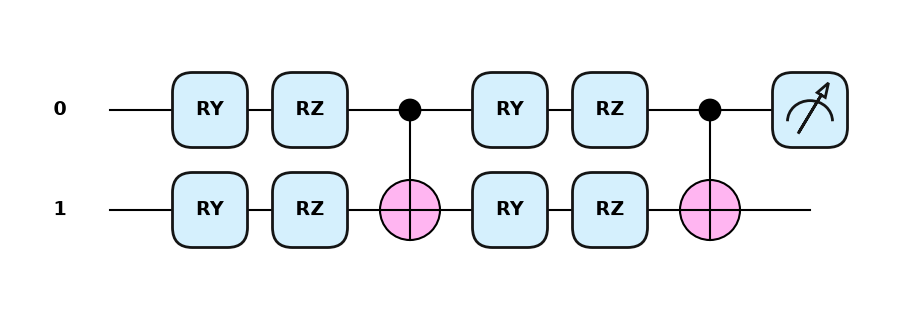

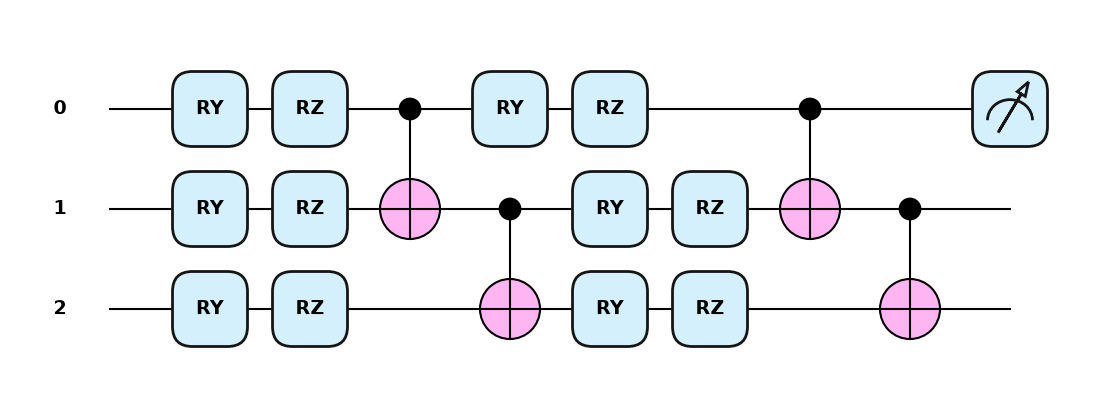

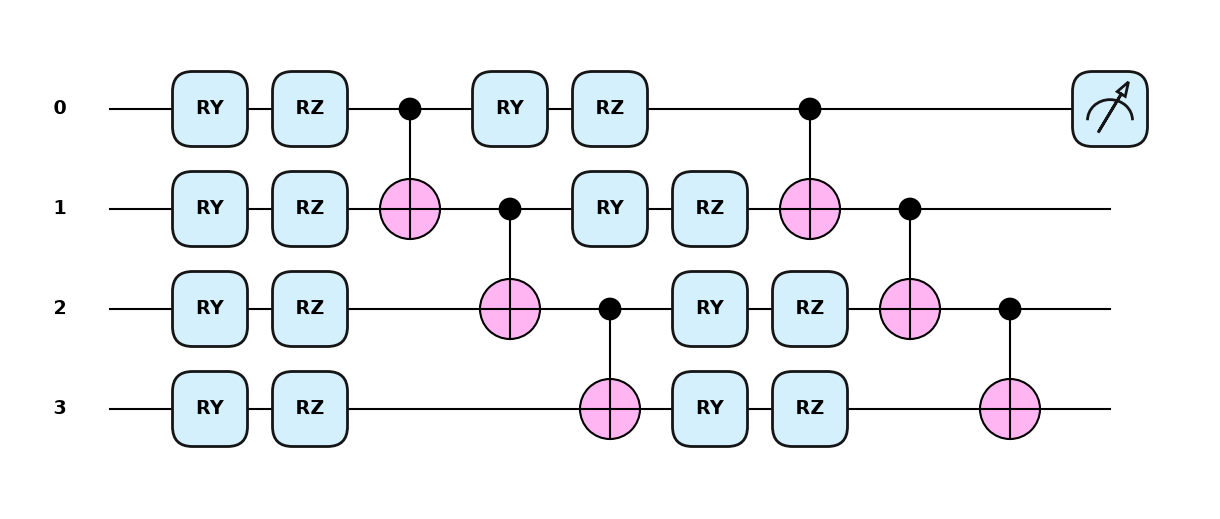

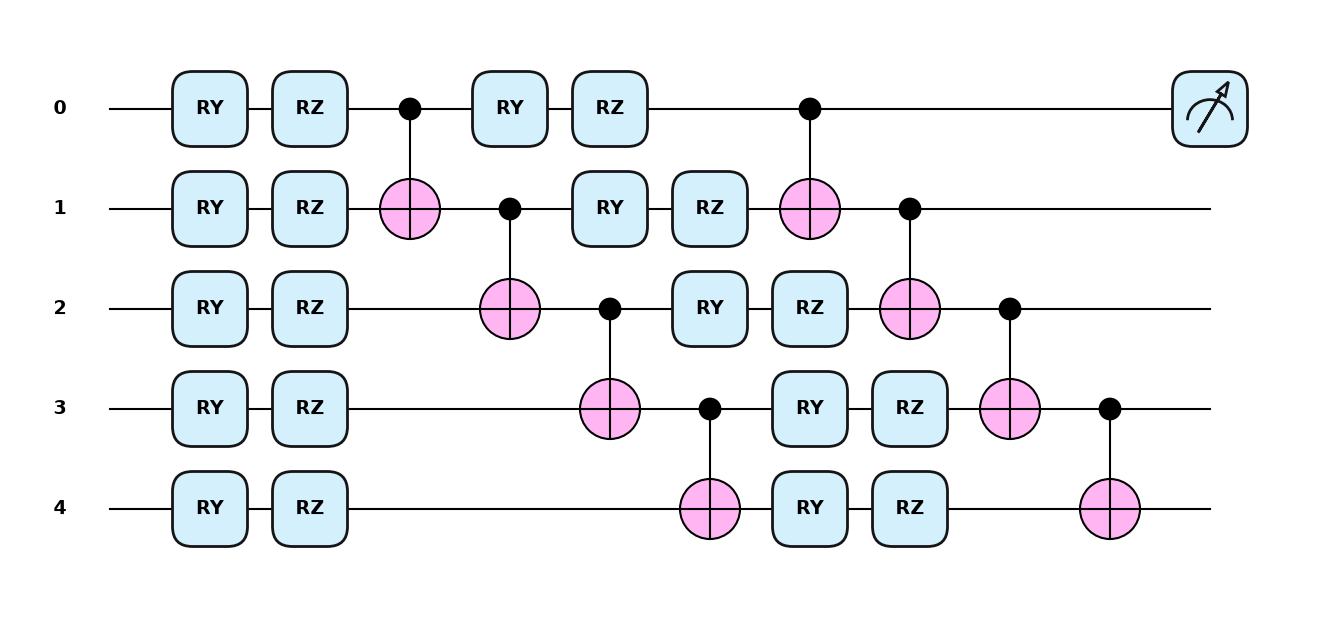

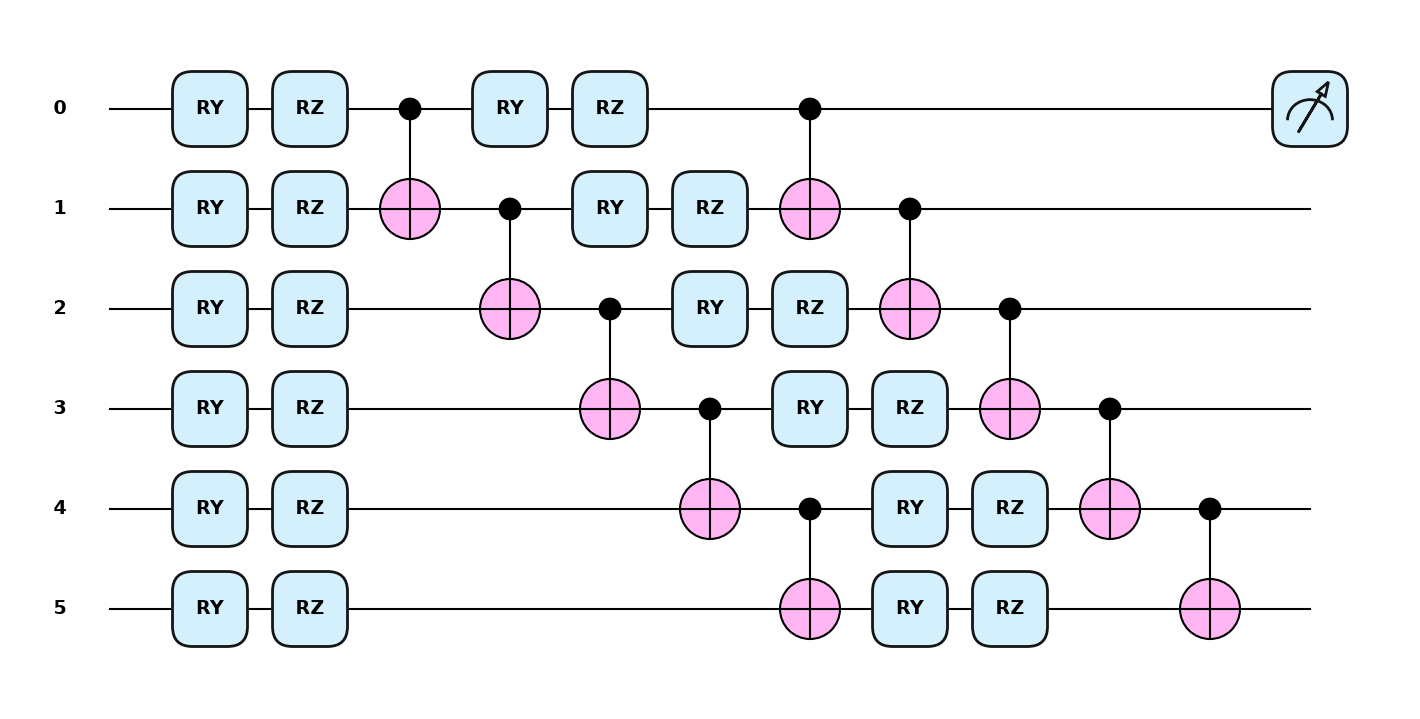

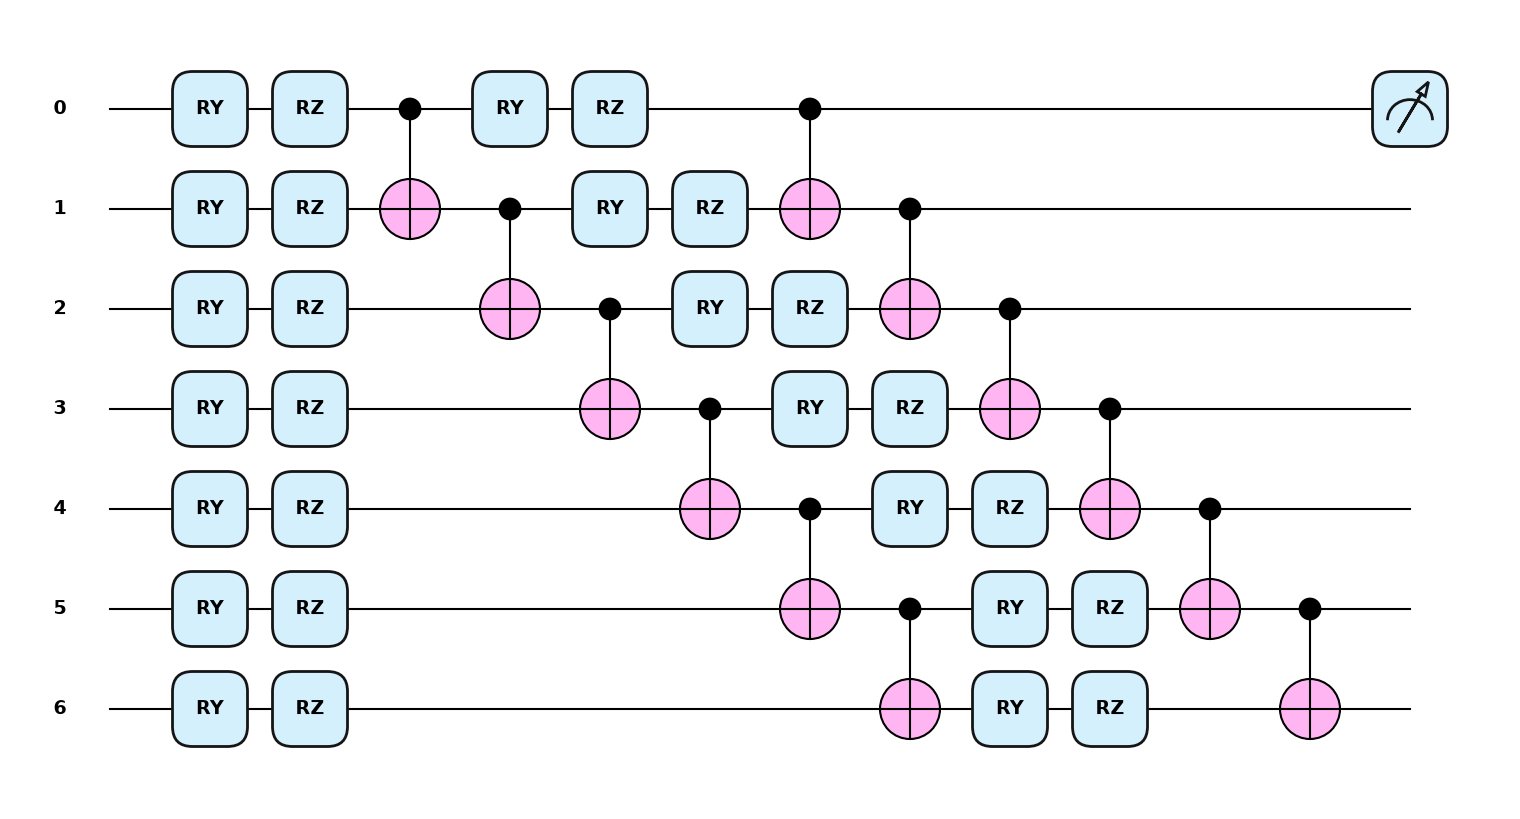

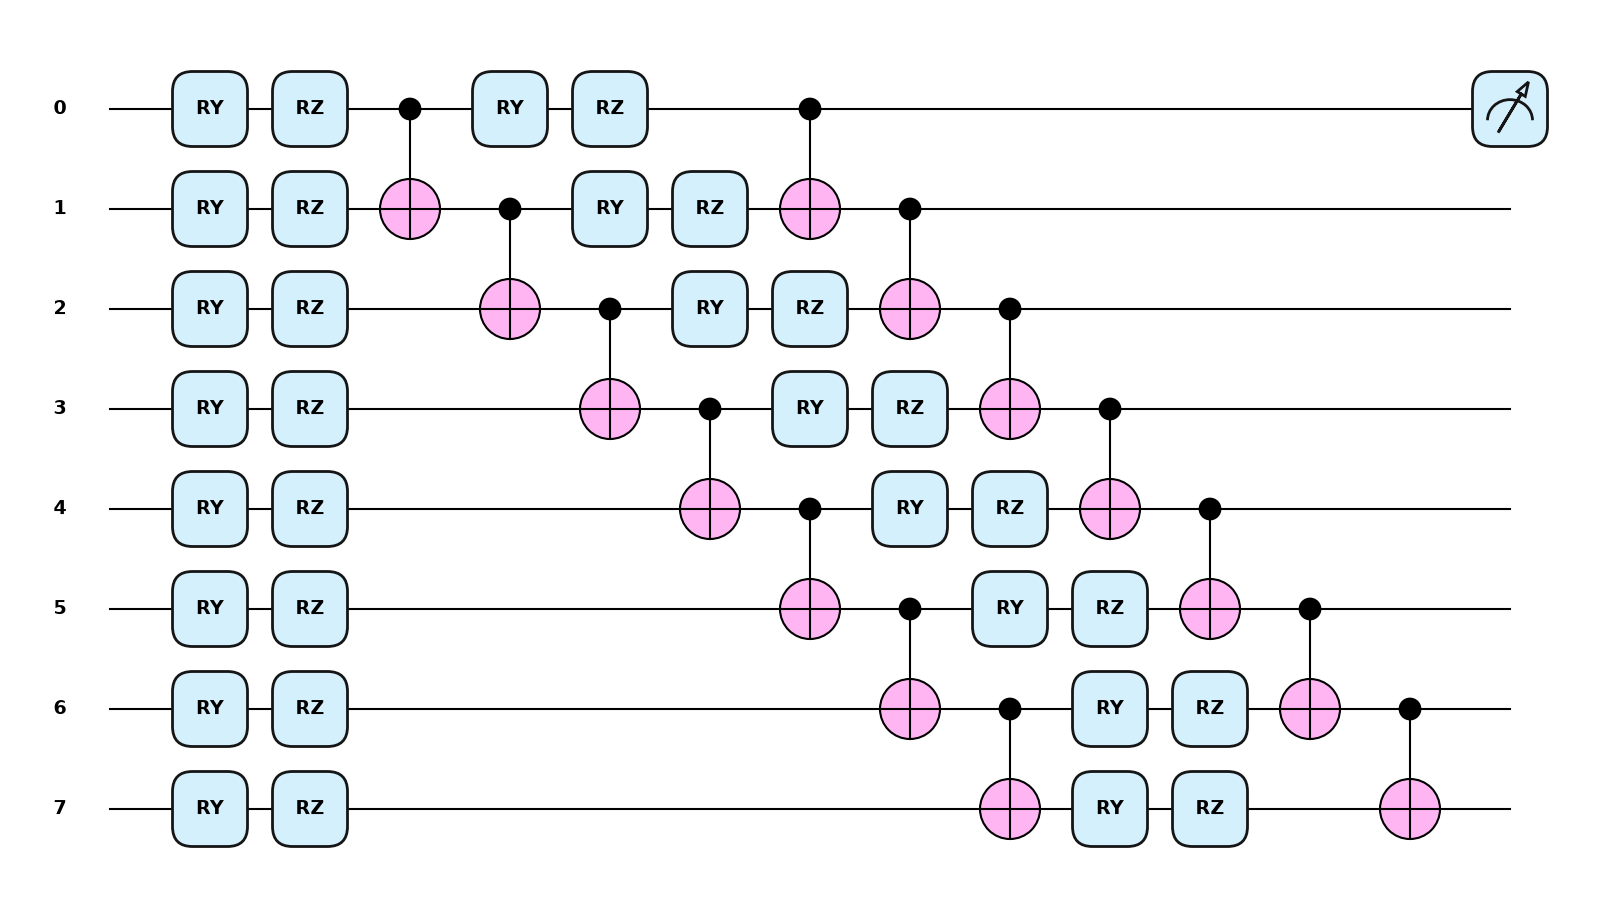

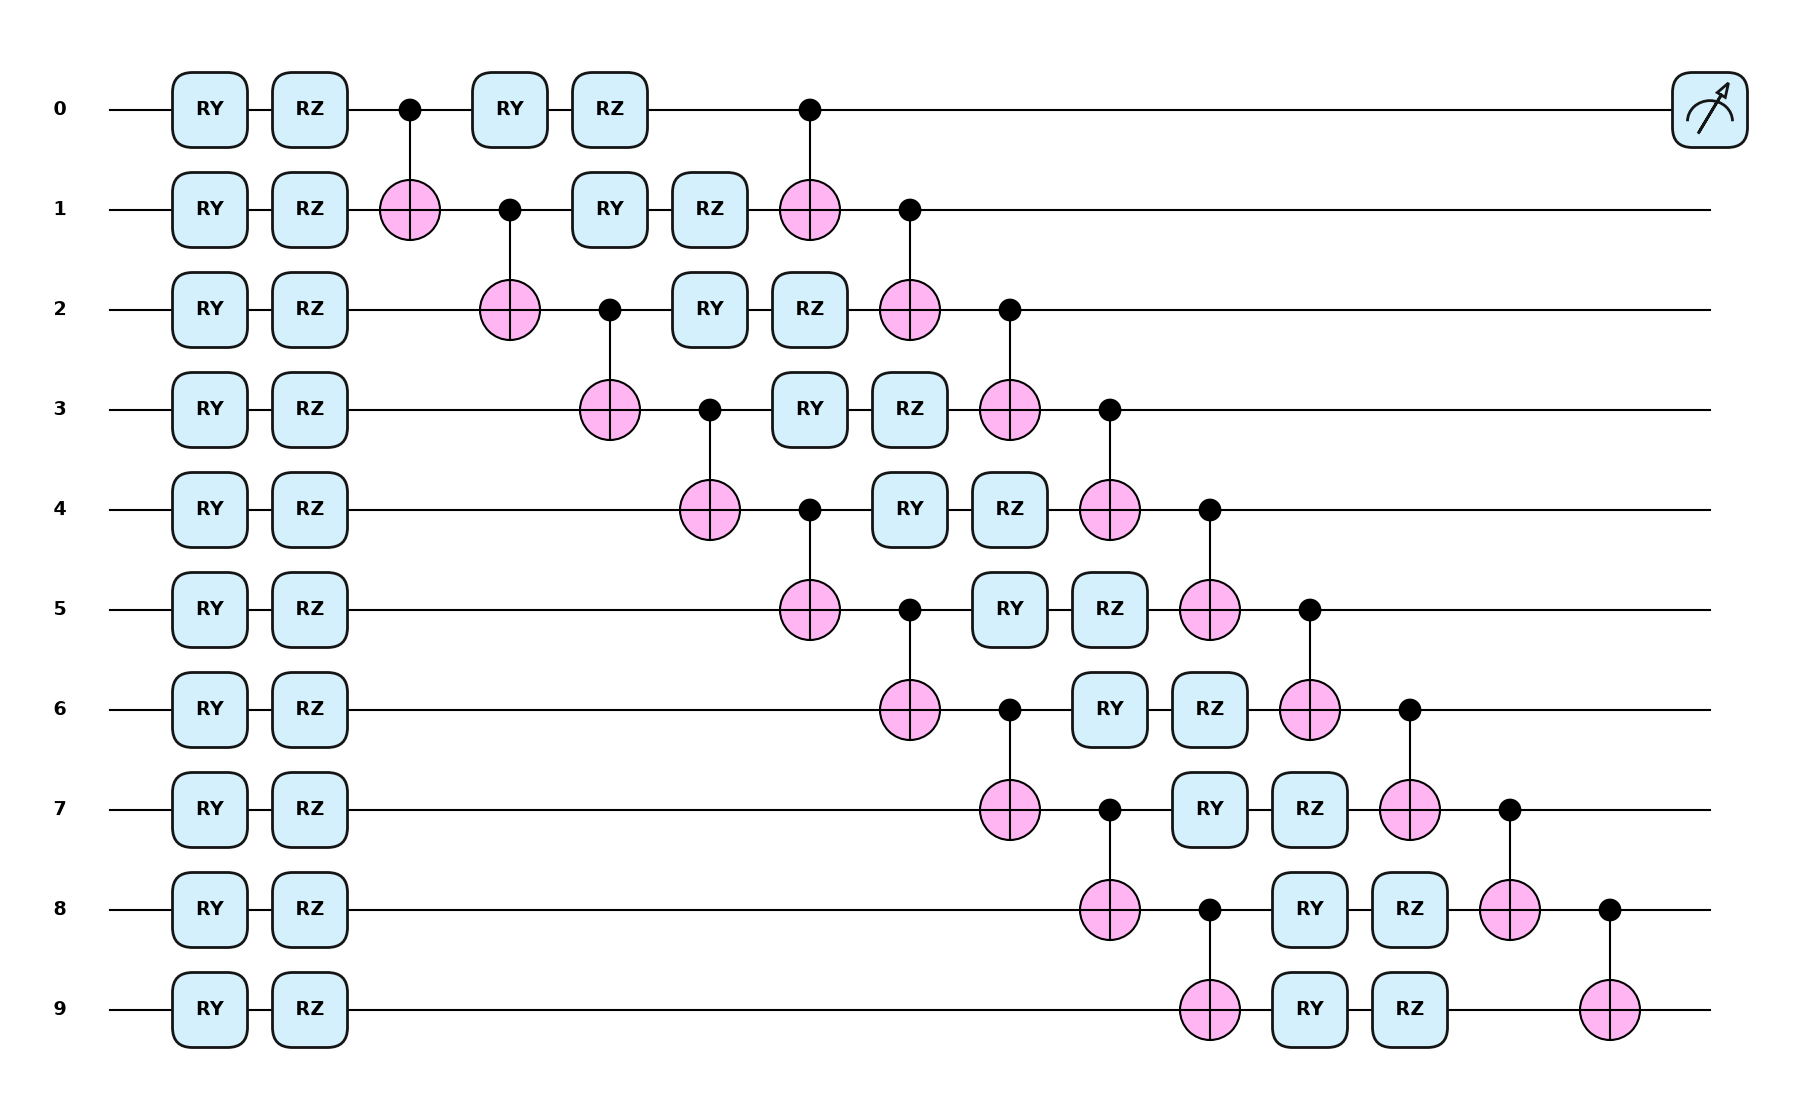

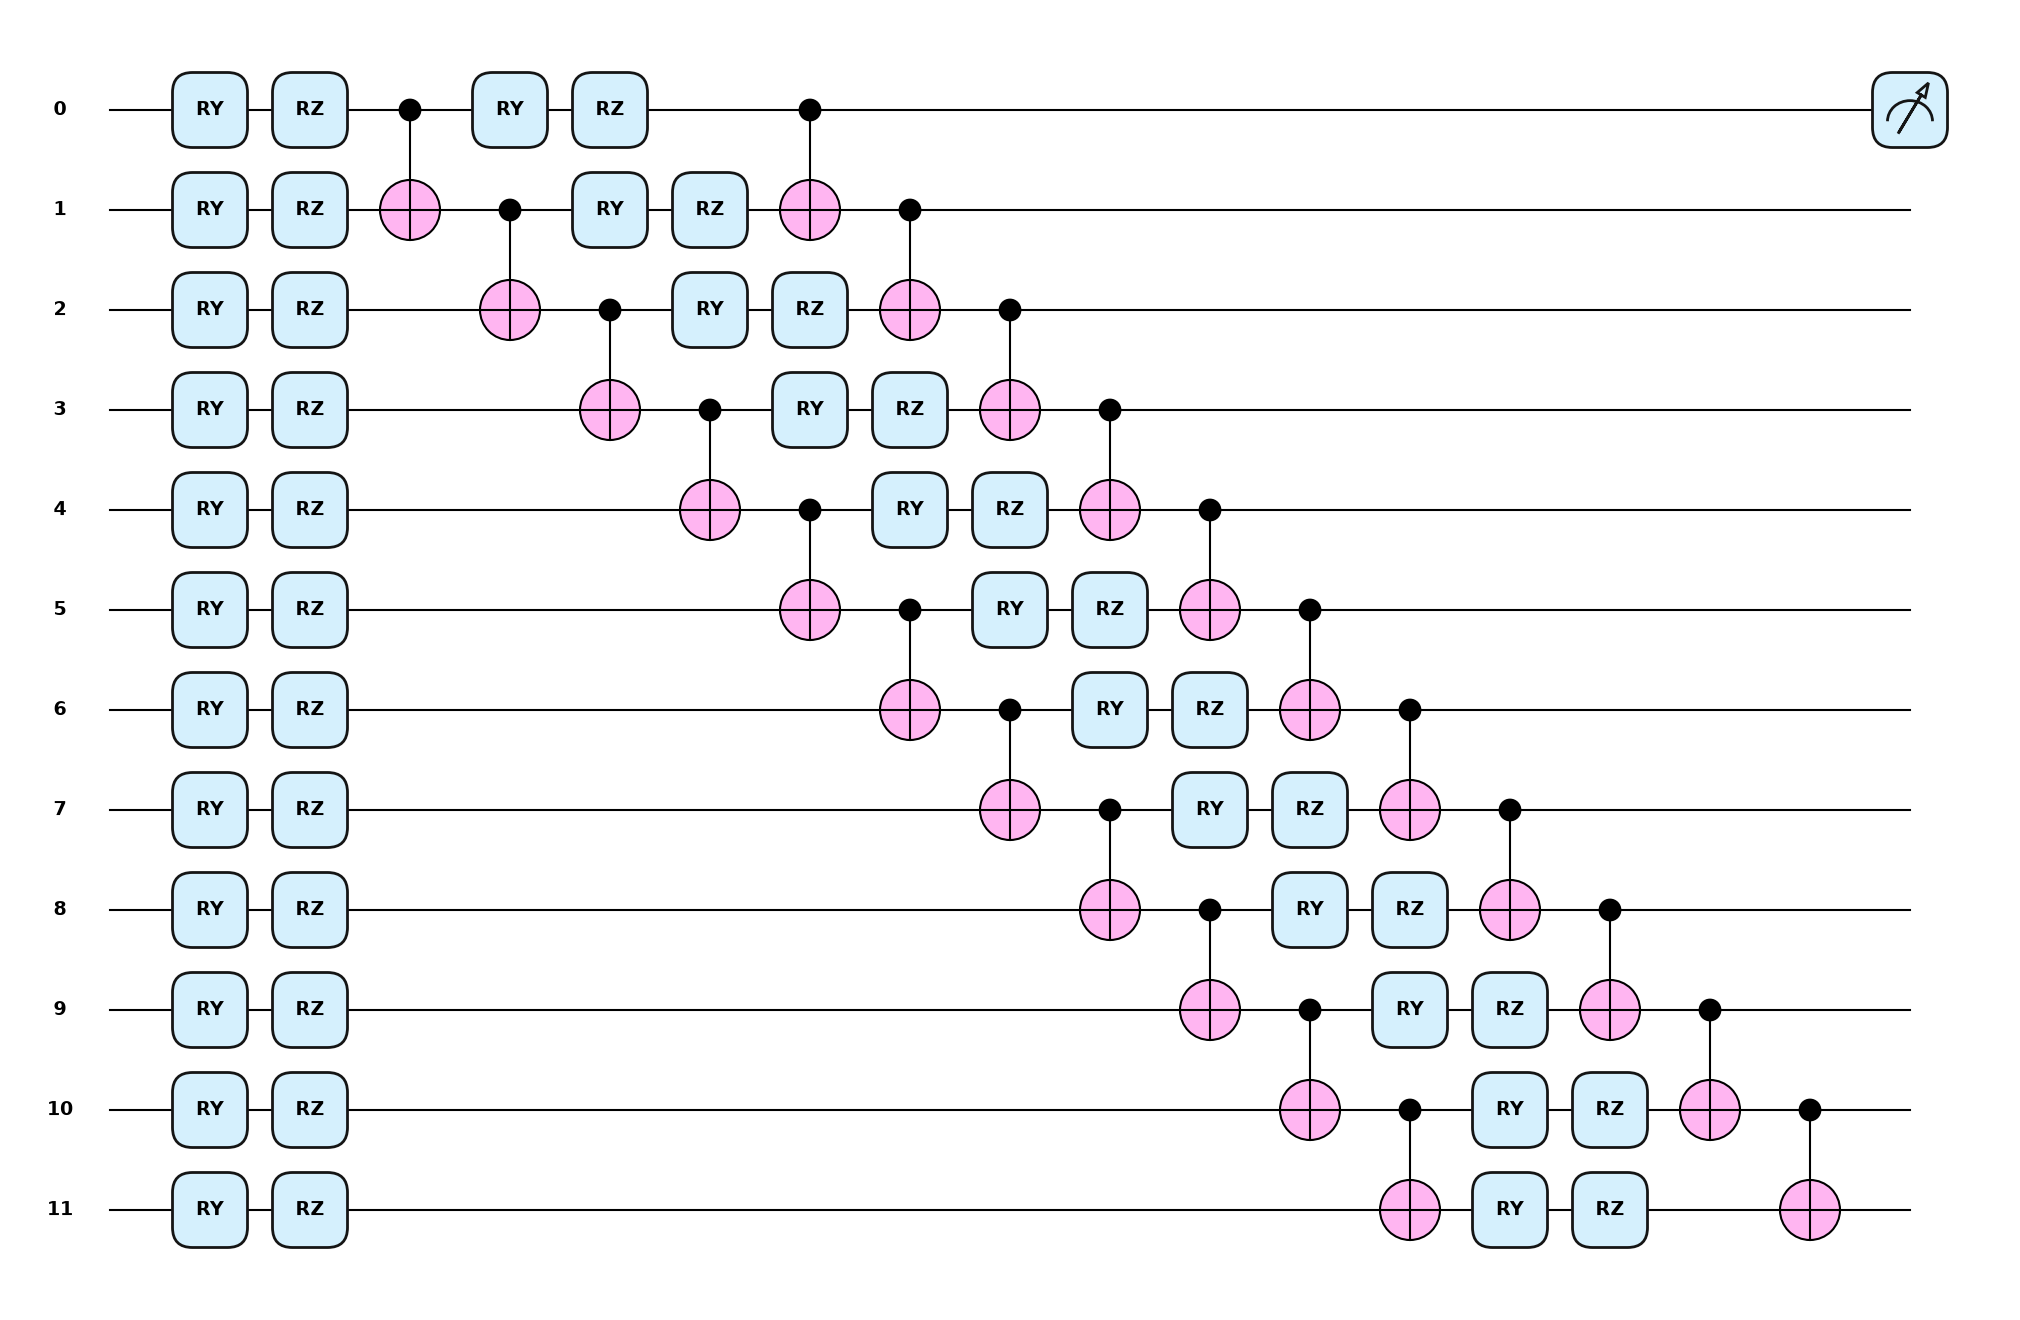

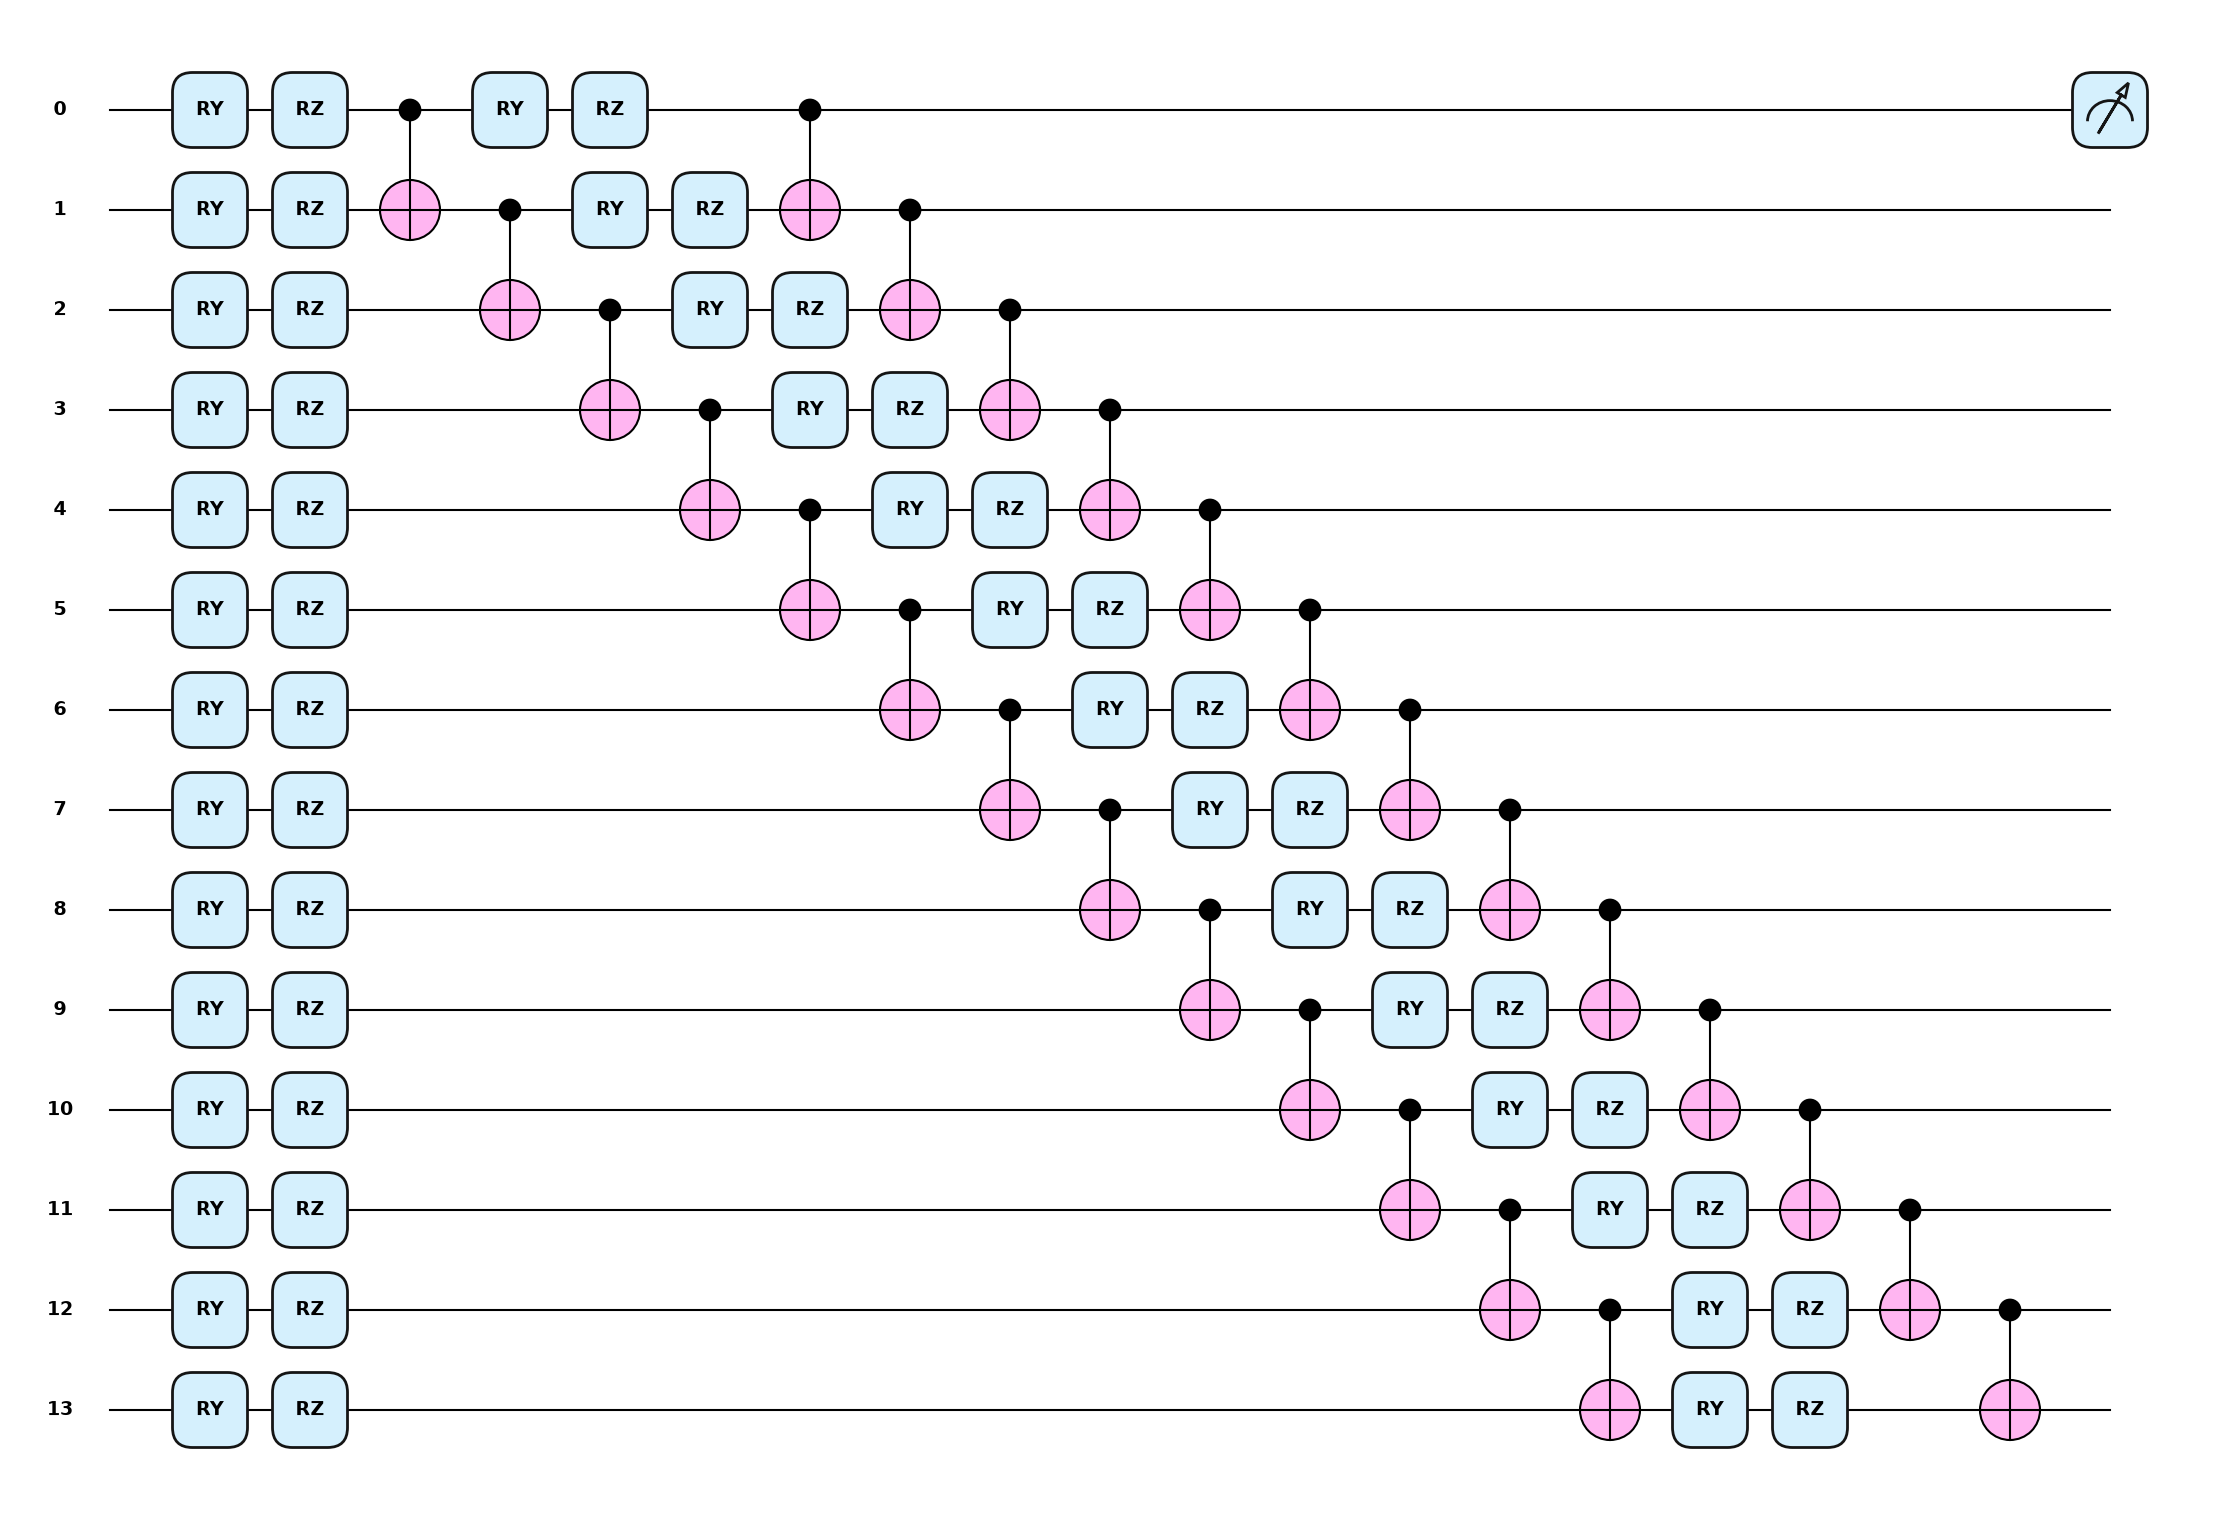

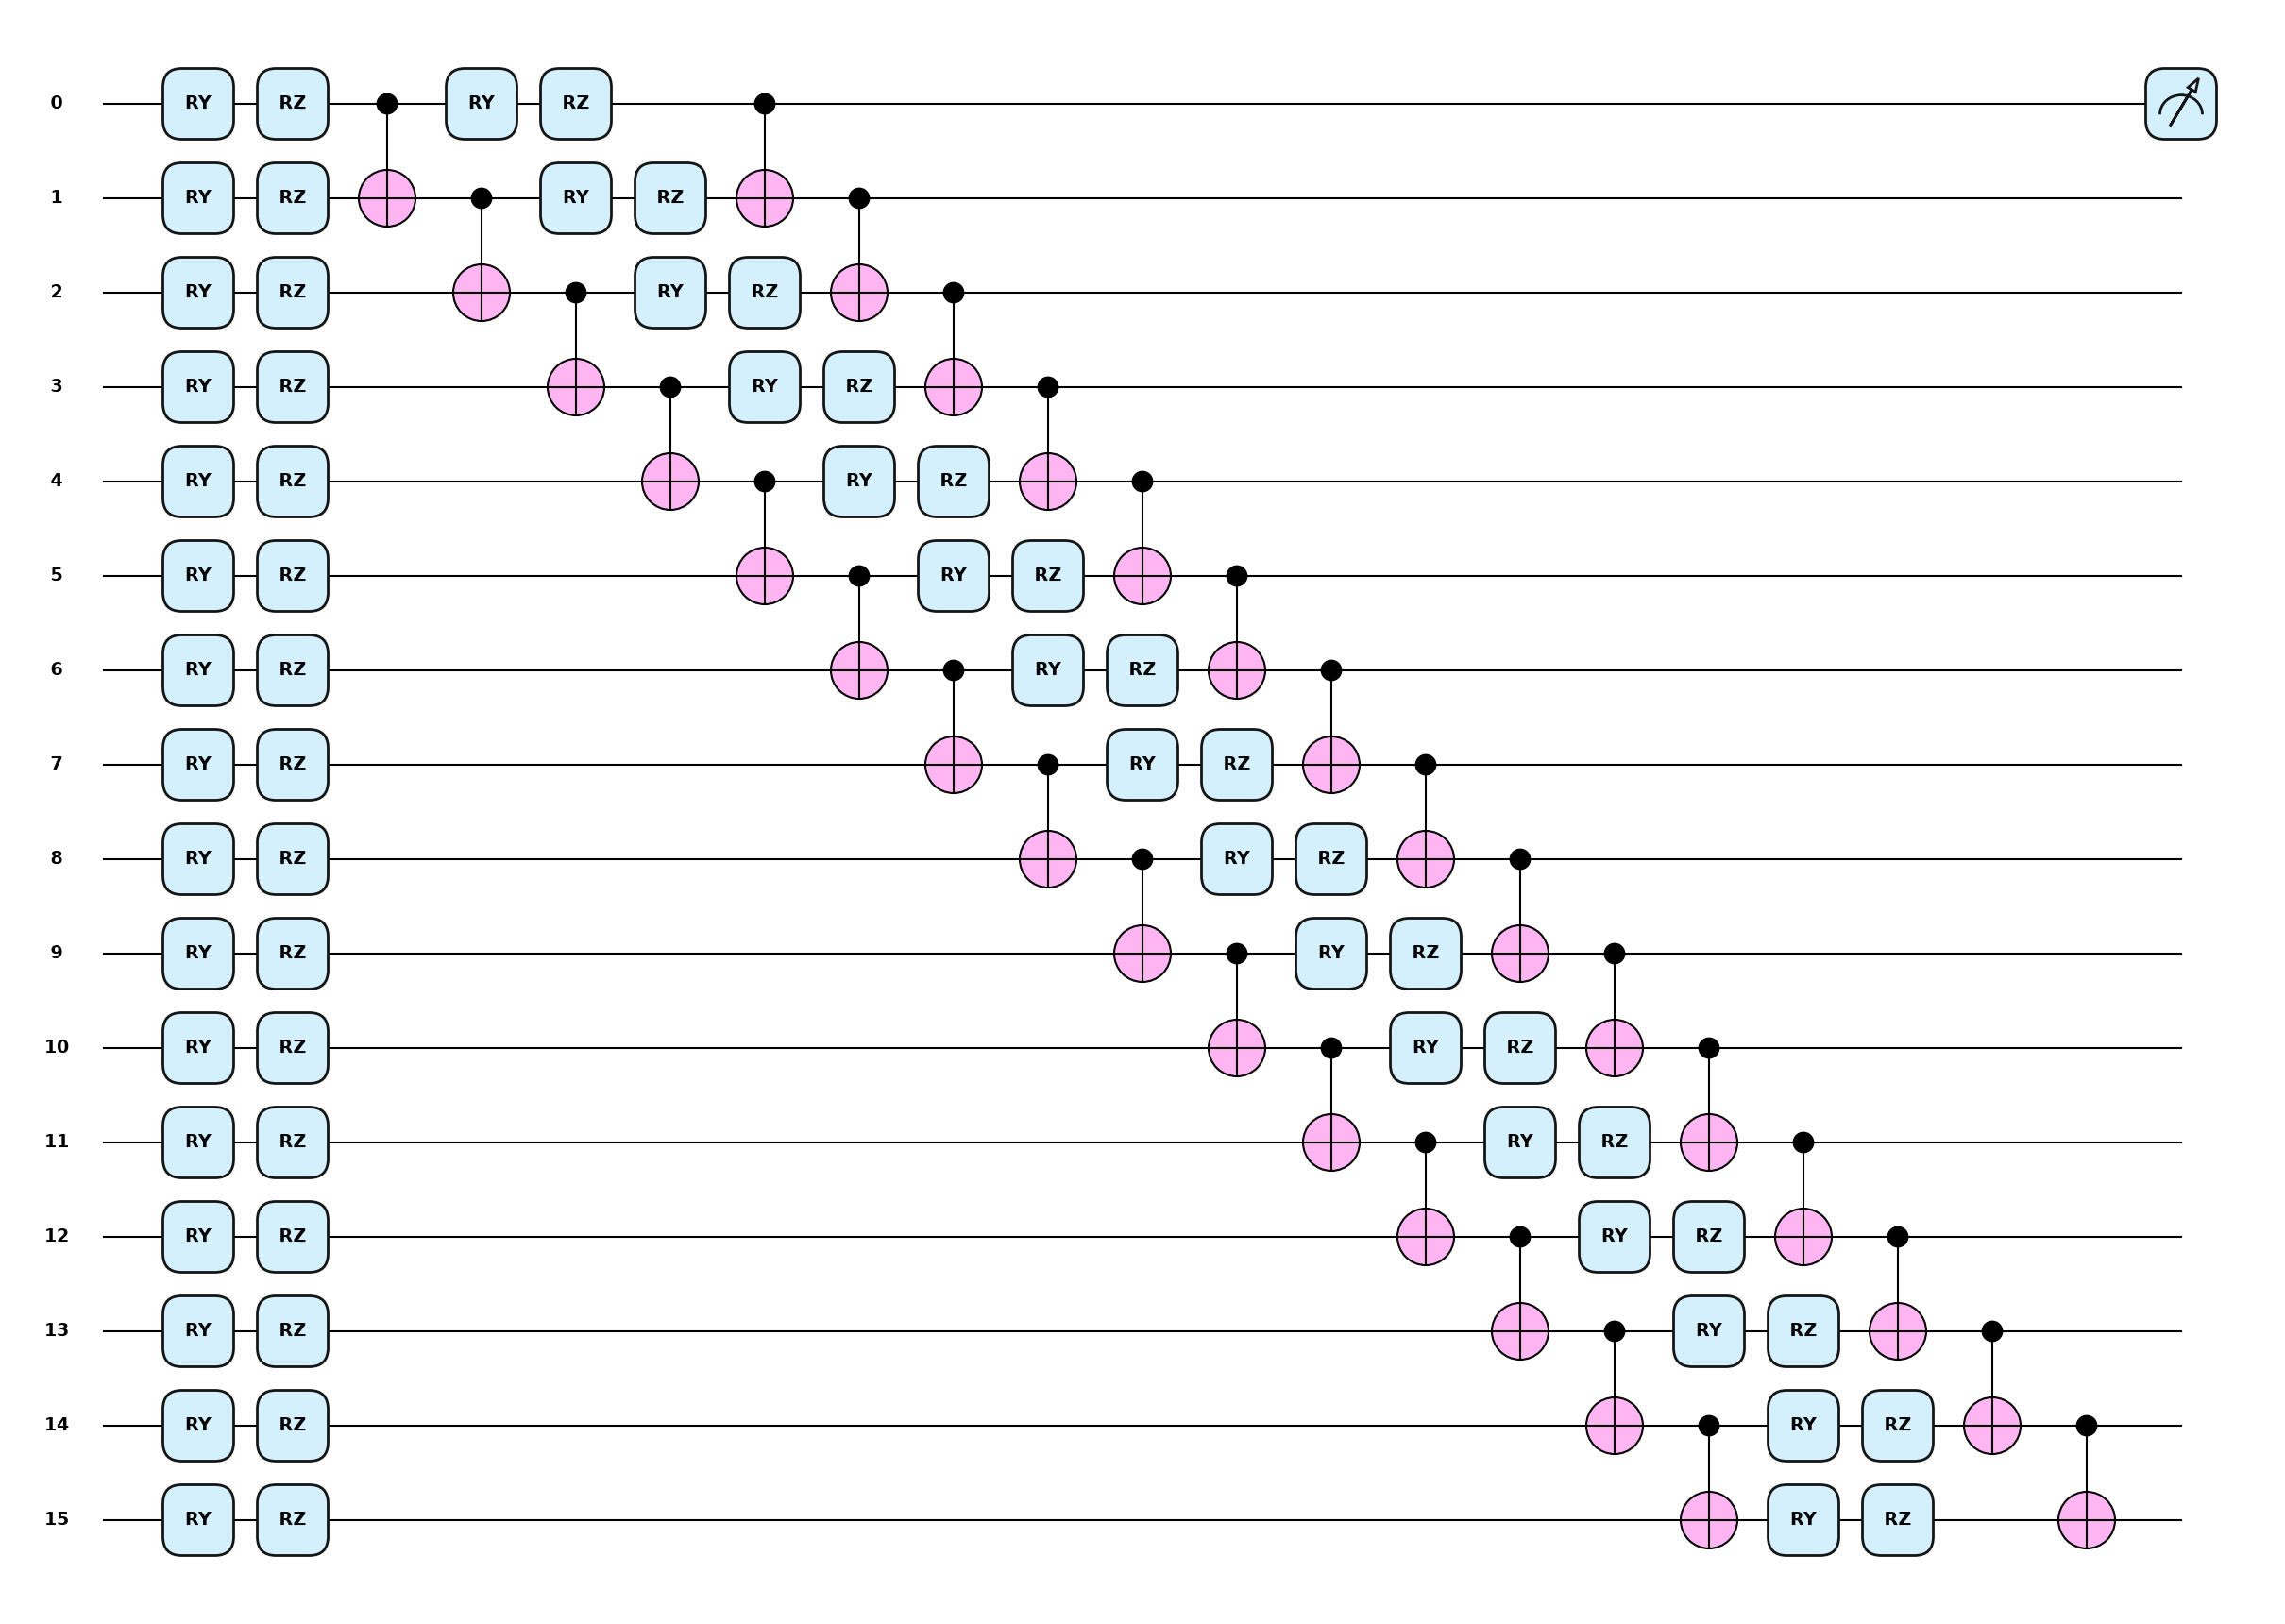

In [33]:
results = []

for test_num in test_count:

    print(f"Running test {test_num}....")
    
    for n_qubits in qubit_counts:

        print(f"Running {n_qubits} qubits...")

        gradients = run_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)
        parameter_var = np.var(gradients,axis=0)
        mean_var = np.mean(parameter_var)

        results.append({"Test": test_num,"Qubits": n_qubits,"Variance": mean_var})
    

In [ ]:
results_df = pd.DataFrame(results)

display(results_df)

qubits = np.array([r["Qubits"] for r in results])
variances = np.array([r["Variance"] for r in results])

std_var = np.std(variances)

print(std_var)

plt.figure(figsize=(8,len(qubit_counts)))

for test_num in test_count:

    data = results_df[results_df["Test"] == test_num]
    plt.plot(data["Qubits"],data["Variance"],marker="o",label=f"Test {test_num}")


plt.yscale("log")

plt.xlabel("N Qubits")
plt.ylabel("Variance")
plt.legend()
plt.grid(True)
plt.show()